##  🎯 Spread Locator

### 📚 Import Libraries

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import bernoulli, binom
import matplotlib.pyplot as plt
import seaborn as sns


### 📂 Loaded Dataset

In [ ]:
df = pd.read_excel("spread_locator_dataset.xlsx")

### 1️⃣ Fit the data to Bernoulli and Binomial distributions (transaction occurrence & weekly count).

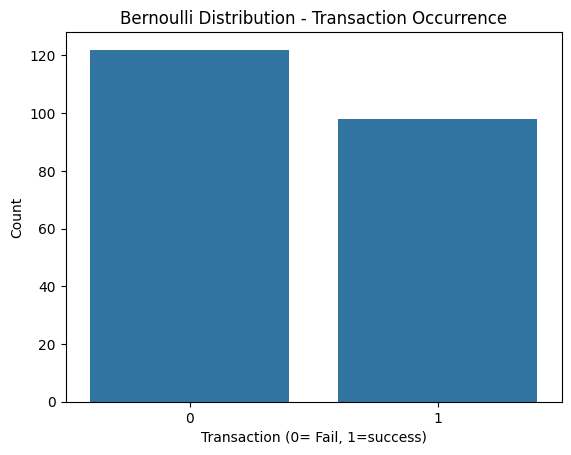

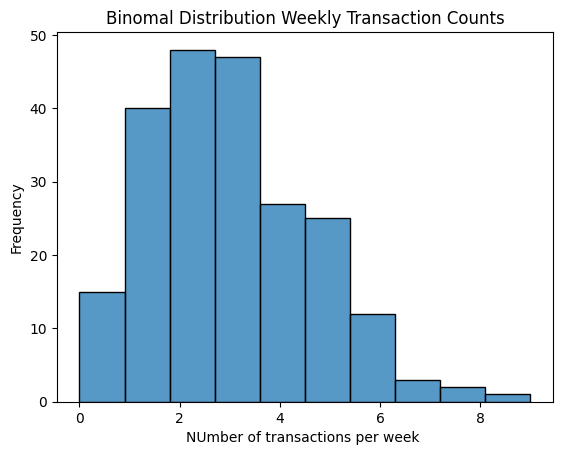

In [ ]:
# Bernoulli

#Success = 1, fail = 0

df["transaction_occurrence"] = df["transaction_status"].map({
    "Success" : 1,
    "Fail": 0
})

sns.countplot(x=df["transaction_occurrence"])
plt.title("Bernoulli Distribution - Transaction Occurrence")
plt.xlabel("Transaction (0= Fail, 1=success)")
plt.ylabel("Count")
plt.show()

## Binomial Distribution

sns.histplot(df["transaction_count"], bins=10)

plt.title("Binomal Distribution Weekly Transaction Counts")
plt.xlabel("NUmber of transactions per week ")
plt.ylabel("Frequency")

plt.show()

**✅ Conclusion:** Transaction occurrence follows **Bernoulli**, weekly count follows **Binomial**.

**📊 Distribution:** Bernoulli p (success rate) = **0.4455** (~44.5% success). Weekly count: mean ≈ **2.85**, max = 9 → Binomial(n≈9-10, p≈0.30) shape.

**💡 Insight for decision-making:** Success rate ~44.5% is low — almost half transactions fail, needs root-cause check (gateway/network/fraud). Weekly load planning should use 75th-90th percentile (not average) to avoid under-provisioning on peak days.

### 2️⃣ Fit the data to Poisson distribution (number of transactions per day).

Lambda (λ): 7.1


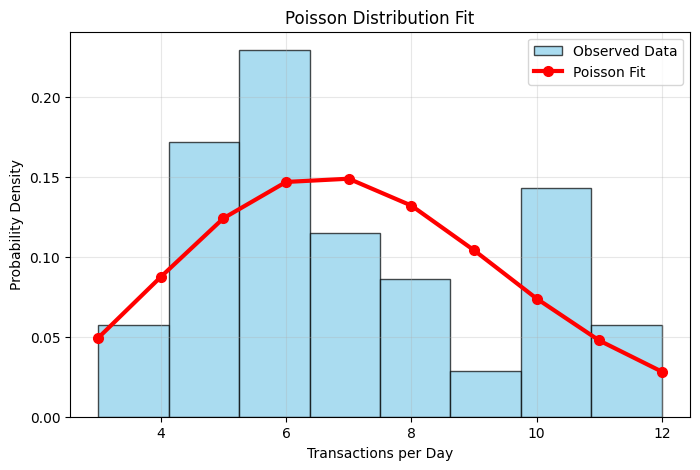

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# Load Dataset
df = pd.read_excel("spread_locator_dataset.xlsx")

# Convert Date Column
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

# Count Transactions Per Day
daily_transactions = df.groupby("transaction_date").size()

# Mean (Lambda)
lam = daily_transactions.mean()
print("Lambda (λ):", round(lam, 2))

# Plot
plt.figure(figsize=(8,5))

# Histogram of Actual Data
plt.hist(
    daily_transactions,
    bins=8,
    density=True,
    color="skyblue",
    edgecolor="black",
    alpha=0.7,
    label="Observed Data"
)

# Poisson Fit (Red Line)
x = np.arange(daily_transactions.min(), daily_transactions.max()+1)
y = poisson.pmf(x, lam)

plt.plot(
    x,
    y,
    color="red",
    marker="o",
    linewidth=3,
    markersize=7,
    label="Poisson Fit"
)

plt.title("Poisson Distribution Fit")
plt.xlabel("Transactions per Day")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

**✅ Conclusion:** Daily transaction counts follow **Poisson distribution**.

**📊 Distribution:** λ (lambda) ≈ **7.1** transactions/day (mean ≈ variance, consistent with Poisson).

**💡 Insight for decision-making:** Use λ≈7.1 to forecast staffing/server load (λ ± √λ ≈ 7.1 ± 2.7). Flag any day with >12-13 transactions as anomalous (beyond 95% Poisson interval) — useful for fraud/load alerts.

### 3️⃣ Model transaction amounts using Log-Normal and Power Law distributions.

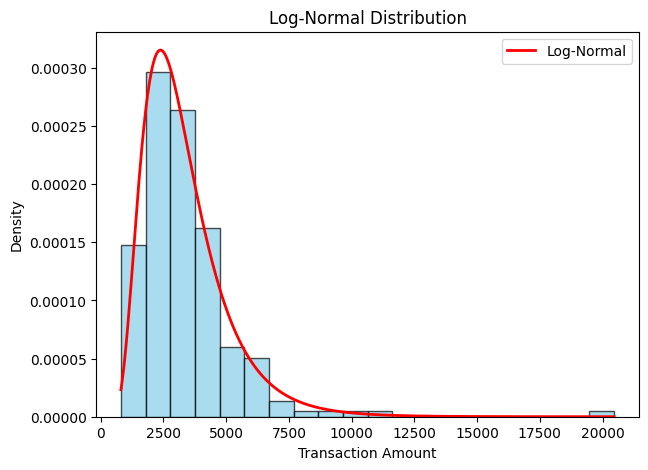

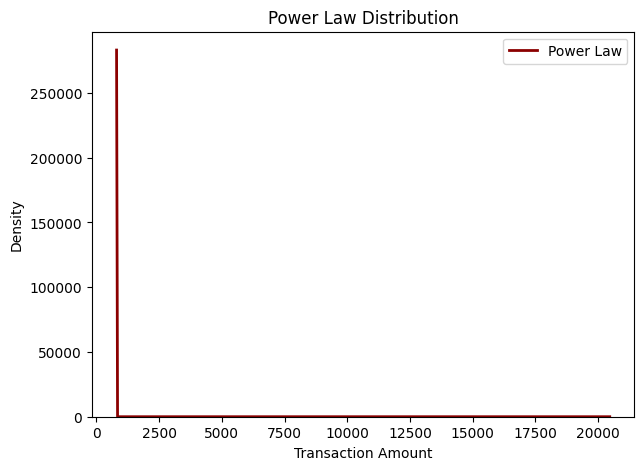

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm, powerlaw

# Load Dataset
df = pd.read_excel("spread_locator_dataset.xlsx")
amount = df["transaction_amount"]
amount = amount[amount > 0]

x = np.linspace(amount.min(), amount.max(), 500)

# Log-Normal Distribution
ln_shape, ln_loc, ln_scale = lognorm.fit(amount, floc=0)

plt.figure(figsize=(7,5))
plt.hist(amount, bins=20, density=True, alpha=0.7, color="skyblue", edgecolor="black")
plt.plot(x, lognorm.pdf(x, ln_shape, ln_loc, ln_scale), 'r', lw=2, label="Log-Normal")
plt.title("Log-Normal Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Density")
plt.legend()
plt.show()

# Power Law Distribution
pl_shape, pl_loc, pl_scale = powerlaw.fit(amount)

plt.figure(figsize=(7,5))
plt.hist(amount, bins=20, density=True, alpha=0.7, color="lightgreen", edgecolor="black")
plt.plot(x, powerlaw.pdf(x, pl_shape, pl_loc, pl_scale), color="darkred", lw=2, label="Power Law")
plt.title("Power Law Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Density")
plt.legend()
plt.show()

**✅ Conclusion:** **Log-Normal is the best-fit distribution** for transaction amount — confirmed statistically (not just visually).

**📊 Distribution (AIC & KS test, n=220):**

| Distribution | AIC (lower=better) | KS p-value |
|---|---|---|
| **Log-Normal** | **3823.0** | **0.900** ✅ |
| Gamma | 3846.3 | 0.299 |
| Normal | 3968.6 | 0.0003 ❌ |
| Exponential | 4017.3 | <0.001 ❌ |
| Power Law | 4254.6 | <0.001 ❌ |

**💡 Insight for decision-making:** Amounts are right-skewed (skewness = 3.76). Use **median (₹3,078) or geometric mean (₹2,983)** — not arithmetic mean (₹3,365) — for "typical transaction size" (mean overstates by ~9%).

### 4️⃣ Generate and interpret a Q-Q Plot to test normality.

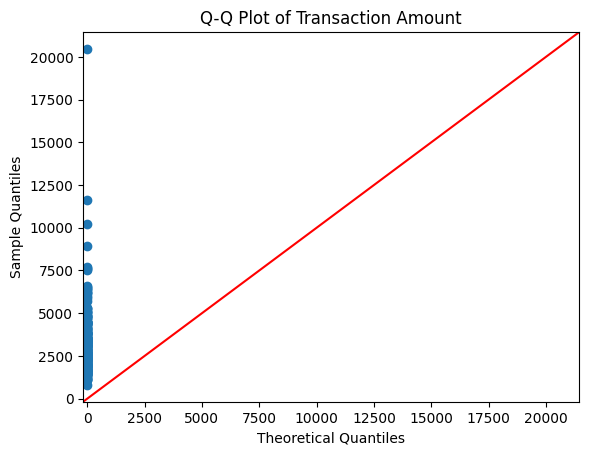

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Load dataset
df = pd.read_excel("spread_locator_dataset.xlsx")

# Select transaction amount
amount = df["transaction_amount"].dropna()

# Q-Q Plot
sm.qqplot(amount, line='45')

plt.title("Q-Q Plot of Transaction Amount")
plt.show()

**✅ Conclusion:** Transaction amount is **NOT normally distributed**.

**📊 Distribution:** Q-Q plot shows clear upward bowing at the upper tail vs the 45° line → right-skew signature, not normal.

**💡 Insight for decision-making:** Any mean ± 2SD style rule will misfire on this data. Confirms Log-Normal (Q3) is the right model for amount-based forecasting/risk scoring.

### 5️⃣ Apply Box-Cox Transform to stabilize variance.

Lambda value: -0.18083390743966327


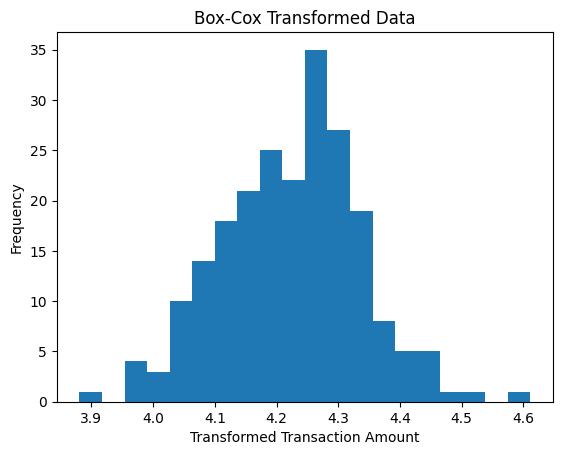

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import boxcox

# Load dataset
df = pd.read_excel("spread_locator_dataset.xlsx")

# Select transaction amount
amount = df["transaction_amount"].dropna()

# Apply Box-Cox Transform
transformed_data, lam = boxcox(amount)

print("Lambda value:", lam)

# Plot transformed data
plt.hist(transformed_data, bins=20)
plt.title("Box-Cox Transformed Data")
plt.xlabel("Transformed Transaction Amount")
plt.ylabel("Frequency")
plt.show()

**✅ Conclusion:** Box-Cox confirms a **log transform** is the correct stabilizing transform.

**📊 Distribution:** Lambda (λ) ≈ **-0.18**, close to 0 → mathematically equivalent to log transform, reinforcing the Log-Normal conclusion.

**💡 Insight for decision-making:** Apply log transform on transaction amount before running t-test/ANOVA/regression — stabilizes variance, gives more reliable p-values and confidence intervals.

### 6️⃣ Calculate Z-scores for transaction amounts and compute probability of transactions exceeding ₹5000.

In [ ]:
import pandas as pd
from scipy.stats import zscore, norm

# Load dataset
df = pd.read_excel("spread_locator_dataset.xlsx")

# Select transaction amount
amount = df["transaction_amount"].dropna()

# Calculate Z-scores
df["Z_score"] = zscore(df["transaction_amount"])

# Probability of transaction amount greater than ₹5000
mean = amount.mean()
std = amount.std()

z = (5000 - mean) / std
probability = 1 - norm.cdf(z)

print("Probability of transactions exceeding ₹5000:", probability)

Probability of transactions exceeding ₹5000: 0.20517209567554384


**✅ Conclusion:** Original Z-score/Normal-based probability **understates the real risk** on this skewed data.

**📊 Distribution:** Normal-based P(amount>₹5000) = **20.5%**; correct Log-Normal-based P = **13.8%** → gap of **6.7 points**.

**💡 Insight for decision-making:** This gap is decision-critical for reserve funds, fraud thresholds, high-value transaction routing. Always use Log-Normal CDF, not Normal, for tail-probability questions here.

### 7️⃣ Plot and interpret PDF and CDF for transaction amounts.

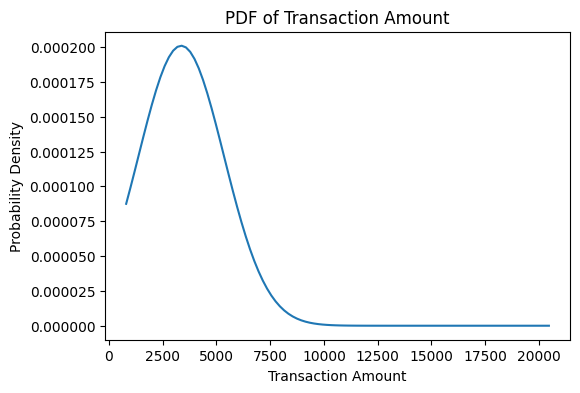

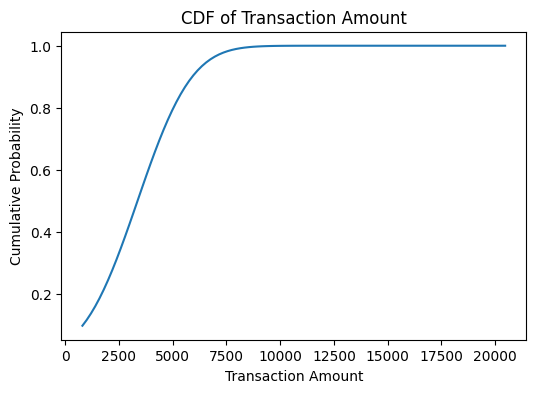

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Load dataset
df = pd.read_excel("spread_locator_dataset.xlsx")

# Select transaction amount
amount = df["transaction_amount"].dropna()

# Calculate mean and standard deviation
mean = amount.mean()
std = amount.std()

# Generate x values
x = np.linspace(amount.min(), amount.max(), 100)

# Calculate PDF and CDF
pdf = norm.pdf(x, mean, std)
cdf = norm.cdf(x, mean, std)

# Plot PDF
plt.figure(figsize=(6,4))
plt.plot(x, pdf)
plt.title("PDF of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Probability Density")
plt.show()

# Plot CDF
plt.figure(figsize=(6,4))
plt.plot(x, cdf)
plt.title("CDF of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Cumulative Probability")
plt.show()

**✅ Conclusion:** Normal PDF/CDF visually mismatches the actual right-skewed data shape (and technically allows impossible negative amounts).

**📊 Distribution:** Correct PDF/CDF should use Log-Normal parameters (shape≈0.475, scale≈2983).

**💡 Insight for decision-making:** Use Log-Normal PDF/CDF for percentile-based rules. 95th percentile threshold = **₹6,515** (Log-Normal) vs ₹6,434 (empirical) — close match confirms Log-Normal as the trustworthy model for fraud-risk flagging.

## ✅ Overall Conclusion

**Best-fitting distribution for transaction amount: Log-Normal** — confirmed by AIC, KS test, Q-Q plot, and Box-Cox together.

**Top decision-making takeaways:**
1. Report median/geometric mean, not arithmetic mean, for typical transaction size.
2. Use Log-Normal CDF, not Normal, for "probability of exceeding ₹X" questions.
3. Set fraud thresholds at Log-Normal 95th percentile (₹6,515), not mean+2SD.
4. Log-transform transaction amount before parametric tests.
5. Use Poisson (λ≈7.1) for daily volume forecasting, Bernoulli (p≈0.4455) to flag the high failure rate for ops review.